In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#main excel
df=pd.read_excel('asia-industry.xlsx')
df=df[(df['year']>=1999) & (df['year']<=2017)].copy()



In [ ]:
#loading other files
df_export=pd.read_excel('export % of GDP.xlsx')
df_long= df_export.melt(id_vars=['Country Code', 'Country Name', 'Series Name', 'Variable Name'],
                        var_name='years_raw',
                        value_name='export_gdp_pct')

df_long

,Country Code,Country Name,Series Name,Variable Name,years_raw,export_gdp_pct
0,MYS,Malaysia,Exports of goods and services (% of GDP),exp_per_GDP,1998 [YR1998],115.743725
1,PHL,Philippines,Exports of goods and services (% of GDP),exp_per_GDP,1998 [YR1998],37.806868
2,SGP,Singapore,Exports of goods and services (% of GDP),exp_per_GDP,1998 [YR1998],166.787571
3,THA,Thailand,Exports of goods and services (% of GDP),exp_per_GDP,1998 [YR1998],57.937303
4,MYS,Malaysia,Exports of goods and services (% of GDP),exp_per_GDP,1999 [YR1999],121.311394
...,...,...,...,...,...,...
79,THA,Thailand,Exports of goods and services (% of GDP),exp_per_GDP,2017 [YR2017],66.672832
80,MYS,Malaysia,Exports of goods and services (% of GDP),exp_per_GDP,2018 [YR2018],68.554971
81,PHL,Philippines,Exports of goods and services (% of GDP),exp_per_GDP,2018 [YR2018],30.213605
82,SGP,Singapore,Exports of goods and services (% of GDP),exp_per_GDP,2018 [YR2018],178.198251


In [ ]:
# # .melt
# id_verse
# var_name
# value_name
#b4
# Country Code,1990 [YR1990],1991 [YR1991],1992 [YR1992]
# AFG,10.5,11.2,10.8
# ALB,15.2,14.8,16.1
#a4
# Country Code,year_raw,exports_gdp_pct
# AFG,1990 [YR1990],10.5
# AFG,1991 [YR1991],11.2
# AFG,1992 [YR1992],10.8
# ALB,1990 [YR1990],15.2
# ALB,1991 [YR1991],14.8
# ALB,1992 [YR1992],16.1


In [ ]:
# The 'years_raw' column does not contain only numerical year, so we need to extract it.
df_long['year_clean'] = df_long['years_raw'].str.extract('(\d{4})').astype(int)

# Display the updated DataFrame (optional)
df_long.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_202/1752635651.py:2: SyntaxWarning: invalid escape sequence '\d'
  df_long['year_clean'] = df_long['years_raw'].str.extract('(\d{4})').astype(int)


,Country Code,Country Name,Series Name,Variable Name,years_raw,export_gdp_pct,year_clean
0,MYS,Malaysia,Exports of goods and services (% of GDP),exp_per_GDP,1998 [YR1998],115.743725,1998
1,PHL,Philippines,Exports of goods and services (% of GDP),exp_per_GDP,1998 [YR1998],37.806868,1998
2,SGP,Singapore,Exports of goods and services (% of GDP),exp_per_GDP,1998 [YR1998],166.787571,1998
3,THA,Thailand,Exports of goods and services (% of GDP),exp_per_GDP,1998 [YR1998],57.937303,1998
4,MYS,Malaysia,Exports of goods and services (% of GDP),exp_per_GDP,1999 [YR1999],121.311394,1999


In [ ]:
# merging

df_data=pd.merge(df,df_long,
                 left_on=['countrycode','year'],
                 right_on=['Country Code','year_clean'],
                 how='left'
                 )

In [ ]:
# df_data = pd.merge(df, df_long,
#                  left_on=['countrycode','year'],
#                  right_on=['Country Code','year_clean'],
#                  how='left')


# df_pop=pd.read_excel('total population.xlsx')
# df_popp_processed = df_pop.melt(id_vars=['Country Code'],
#                              value_vars=[col for col in df_pop.columns if isinstance(col, (int, float)) or 'YR' in str(col)],
#                              var_name='Years_raw_pop',
#                              value_name='population_total')

# df_popp_processed['year'] = df_popp_processed['Years_raw_pop'].astype(str).str.extract(r'(\d{4})').astype(int)
# df_popp_processed.drop(columns=['Years_raw_pop'], inplace=True)
# df_popp_processed.rename(columns={'Country Code': 'countrycode'}, inplace=True)


# # GDP
# df_gdp=pd.read_excel('GDP per Capital PPP (2021 constant international $).xlsx')
# df_gdpm_processed = df_gdp.melt(id_vars=['Country Code'],
#                              value_vars=[col for col in df_gdp.columns if isinstance(col, (int, float)) or 'YR' in str(col)],
#                              var_name='Years_raw_gdp',
#                              value_name='gdp_per_capita')

# df_gdpm_processed['year'] = df_gdpm_processed['Years_raw_gdp'].astype(str).str.extract(r'(\d{4})').astype(int)
# df_gdpm_processed.drop(columns=['Years_raw_gdp'], inplace=True)

# df_gdpm_processed['gdp_per_capita'] = pd.to_numeric(df_gdpm_processed['gdp_per_capita'], errors='coerce').astype('Int64')

# df_gdpm_processed.rename(columns={'Country Code': 'countrycode'}, inplace=True)


# #Merge population into our growing df_data
# df_data = pd.merge(df_data,
#                   df_popp_processed,
#                   on=['countrycode', 'year'],
#                   how='left'
#                  )


# #Merge GDP
# df_data = pd.merge(df_data,
#                   df_gdpm_processed,
#                   on=['countrycode', 'year'],
#                   how='left'
#                  )

In [ ]:

df_pop = pd.read_excel('total population.xlsx')

# Melt
df_pop_long = df_pop.melt(id_vars=['Country Code'], var_name='year_raw', value_name='pop_total')


df_pop_long['year_clean'] = df_pop_long['year_raw'].str.extract('(\d{4})')


df_pop_long = df_pop_long.dropna(subset=['year_clean'])

df_pop_long['year'] = df_pop_long['year_clean'].astype(int)



df_gdp = pd.read_excel('GDP per Capital PPP (2021 constant international $).xlsx')

df_gdp_long = df_gdp.melt(id_vars=['Country Code'], var_name='year_raw', value_name='gdp_pcap_ppp')

df_gdp_long['year_clean'] = df_gdp_long['year_raw'].str.extract('(\d{4})')

df_gdp_long = df_gdp_long.dropna(subset=['year_clean'])

df_gdp_long['year'] = df_gdp_long['year_clean'].astype(int)

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_202/3468110897.py:7: SyntaxWarning: invalid escape sequence '\d'
  df_pop_long['year_clean'] = df_pop_long['year_raw'].str.extract('(\d{4})')
/tmp/ipykernel_202/3468110897.py:20: SyntaxWarning: invalid escape sequence '\d'
  df_gdp_long['year_clean'] = df_gdp_long['year_raw'].str.extract('(\d{4})')


In [ ]:
# Merge population into our growing df_data
df_pop_long = df_pop_long.rename(columns={'Country Code': 'countrycode'})

df_dataF = pd.merge(df_data,
                  df_pop_long,
                  on=['countrycode', 'year'],
                  how='left'
                 )


# Merge GDP
df_gdp_long = df_gdp_long.rename(columns={'Country Code': 'countrycode'})

df_data_final = pd.merge(df_dataF,
                  df_gdp_long,
                  on=['countrycode', 'year'],
                  how='left'
                 )

In [ ]:
df_data_final

,country,countrycode,year,month,cpi_yoy_nsa,exchnage_rate_vs_usd,ind_prod_const_sa,usa_imp_sa,Country Code,Country Name,...,Variable Name,years_raw,export_gdp_pct,year_clean_x,year_raw_x,pop_total,year_clean_y,year_raw_y,gdp_pcap_ppp,year_clean
0,Malaysia,MYS,1999,1,5.181375,3.800000,4.577605e+09,77781.000000,MYS,Malaysia,...,exp_per_GDP,1999 [YR1999],121.311394,1999,1999,22435531,1999,1999,17428.625656,1999
1,Singapore,SGP,1999,1,-0.661324,1.678571,2.589487e+09,77781.000000,SGP,Singapore,...,exp_per_GDP,1999 [YR1999],176.745013,1999,1999,3958723,1999,1999,63746.479223,1999
2,Philippines,PHL,1999,1,10.555900,38.294286,6.522064e+09,77781.000000,PHL,Philippines,...,exp_per_GDP,1999 [YR1999],38.411159,1999,1999,77753257,1999,1999,4650.759269,1999
3,Thailand,THA,1999,1,3.273102,36.593810,6.098279e+09,77781.000000,THA,Thailand,...,exp_per_GDP,1999 [YR1999],56.438543,1999,1999,62299043,1999,1999,11253.387496,1999
4,Singapore,SGP,1999,2,-0.987156,1.699600,2.692236e+09,79842.000000,SGP,Singapore,...,exp_per_GDP,1999 [YR1999],176.745013,1999,1999,3958723,1999,1999,63746.479223,1999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,Singapore,SGP,2017,11,0.612723,1.355182,7.093773e+09,203973.271221,SGP,Singapore,...,exp_per_GDP,2017 [YR2017],171.741626,2017,2017,5612253,2017,2017,116471.820765,2017
908,Malaysia,MYS,2017,12,3.588902,4.067065,1.100520e+10,208877.825476,MYS,Malaysia,...,exp_per_GDP,2017 [YR2017],70.011743,2017,2017,32355644,2017,2017,29551.54576,2017
909,Thailand,THA,2017,12,0.761127,32.554595,1.300725e+10,208877.825476,THA,Thailand,...,exp_per_GDP,2017 [YR2017],66.672832,2017,2017,71160187,2017,2017,20094.677876,2017
910,Philippines,PHL,2017,12,3.074009,50.478905,9.533997e+09,208877.825476,PHL,Philippines,...,exp_per_GDP,2017 [YR2017],29.552291,2017,2017,108119693,2017,2017,8584.136227,2017


In [ ]:
df_data_final.to_csv('df_data_final', index=False)
print("Merged dataset saved to 'df_merged.csv'")

Merged dataset saved to 'df_merged.csv'


In [ ]:
df_data_final.to_excel('df_data_final.xlsx', index=False)
print("Merged dataset saved to 'df_data_final.xlsx'")

Merged dataset saved to 'df_data_final.xlsx'


In [ ]:
# Creating LAG space
df_data_final['USA_lag']= df_data_final.groupby('countrycode')['usa_imp_sa'].shift(1)

In [ ]:
# now cleanning
cols= ['country', 'countrycode', 'year','month',
       'cpi_yoy_nsa','USA_lag',	'exchnage_rate_vs_usd',	'ind_prod_const_sa',	'usa_imp_sa', 'Country Code',	'Country Name', 'gdp_pcap_ppp','pop_total','export_gdp_pct']

df_dataset= df_data_final[cols]
df_dataset= df_dataset.dropna(subset=['USA_lag'])
df_dataset.head()

,country,countrycode,year,month,cpi_yoy_nsa,USA_lag,exchnage_rate_vs_usd,ind_prod_const_sa,usa_imp_sa,Country Code,Country Name,gdp_pcap_ppp,pop_total,export_gdp_pct
4,Singapore,SGP,1999,2,-0.987156,77781.0,1.699600,2.692236e+09,79842.0,SGP,Singapore,63746.479223,3958723,176.745013
5,Philippines,PHL,1999,2,9.055043,77781.0,38.811250,6.383731e+09,79842.0,PHL,Philippines,4650.759269,77753257,38.411159
6,Thailand,THA,1999,2,2.488452,77781.0,37.060500,5.710419e+09,79842.0,THA,Thailand,11253.387496,62299043,56.438543
7,Malaysia,MYS,1999,2,3.850393,77781.0,3.800000,4.915195e+09,79842.0,MYS,Malaysia,17428.625656,22435531,121.311394
8,Singapore,SGP,1999,3,-0.519663,79842.0,1.729435,2.751341e+09,79569.0,SGP,Singapore,63746.479223,3958723,176.745013


In [ ]:
# Creating log transformations
df_dataset['log_ind_prod_sa']=np.log(df_dataset['ind_prod_const_sa'])
df_dataset['log_usa_imp']= np.log(df_dataset['USA_lag'])

In [ ]:
# EDA

df_dataset.info()
df
df_dataset.isnull().sum()
df_dataset.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 908 entries, 4 to 911
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               908 non-null    object 
 1   countrycode           908 non-null    object 
 2   year                  908 non-null    int64  
 3   month                 908 non-null    int64  
 4   cpi_yoy_nsa           908 non-null    float64
 5   USA_lag               908 non-null    float64
 6   exchnage_rate_vs_usd  908 non-null    float64
 7   ind_prod_const_sa     908 non-null    float64
 8   usa_imp_sa            908 non-null    float64
 9   Country Code          908 non-null    object 
 10  Country Name          908 non-null    object 
 11  gdp_pcap_ppp          908 non-null    object 
 12  pop_total             908 non-null    object 
 13  export_gdp_pct        908 non-null    float64
 14  log_ind_prod_sa       908 non-null    float64
 15  log_usa_imp           908 no

,year,month,cpi_yoy_nsa,USA_lag,exchnage_rate_vs_usd,ind_prod_const_sa,usa_imp_sa,export_gdp_pct,log_ind_prod_sa,log_usa_imp
count,908.000000,908.000000,908.000000,908.000000,908.000000,9.080000e+02,908.000000,908.000000,908.000000,908.000000
mean,2008.039648,6.524229,2.596313,149817.076653,22.200371,7.455059e+09,150394.595708,98.169261,22.666602,11.880285
std,5.459541,3.442145,2.213753,38383.704374,20.333632,2.627273e+09,38281.498201,62.247842,0.371682,0.280014
min,1999.000000,1.000000,-4.272440,77781.000000,1.209087,2.692236e+09,79569.000000,26.177420,21.713638,11.261652
25%,2003.000000,4.000000,1.160243,106396.000000,2.698609,5.865551e+09,107040.000000,53.164962,22.492362,11.574923
50%,2008.000000,7.000000,2.373582,157913.000000,16.767580,6.586727e+09,158128.000000,69.730217,22.608322,11.969800
75%,2013.000000,10.000000,3.629721,186853.700834,41.959644,9.164940e+09,186963.000000,132.121211,22.938651,12.138081
max,2017.000000,12.000000,10.679436,203973.271221,56.330952,1.326830e+10,208877.825476,228.993771,23.308644,12.225744


In [ ]:
# Adding a detailed summary here
eda_summary= df_dataset.describe().T
eda_summary

,count,mean,std,min,25%,50%,75%,max
year,908.0,2.008040e+03,5.459541e+00,1.999000e+03,2.003000e+03,2.008000e+03,2.013000e+03,2.017000e+03
month,908.0,6.524229e+00,3.442145e+00,1.000000e+00,4.000000e+00,7.000000e+00,1.000000e+01,1.200000e+01
cpi_yoy_nsa,908.0,2.596313e+00,2.213753e+00,-4.272440e+00,1.160243e+00,2.373582e+00,3.629721e+00,1.067944e+01
USA_lag,908.0,1.498171e+05,3.838370e+04,7.778100e+04,1.063960e+05,1.579130e+05,1.868537e+05,2.039733e+05
exchnage_rate_vs_usd,908.0,2.220037e+01,2.033363e+01,1.209087e+00,2.698609e+00,1.676758e+01,4.195964e+01,5.633095e+01
ind_prod_const_sa,908.0,7.455059e+09,2.627273e+09,2.692236e+09,5.865551e+09,6.586727e+09,9.164940e+09,1.326830e+10
usa_imp_sa,908.0,1.503946e+05,3.828150e+04,7.956900e+04,1.070400e+05,1.581280e+05,1.869630e+05,2.088778e+05
export_gdp_pct,908.0,9.816926e+01,6.224784e+01,2.617742e+01,5.316496e+01,6.973022e+01,1.321212e+02,2.289938e+02
log_ind_prod_sa,908.0,2.266660e+01,3.716818e-01,2.171364e+01,2.249236e+01,2.260832e+01,2.293865e+01,2.330864e+01
log_usa_imp,908.0,1.188029e+01,2.800143e-01,1.126165e+01,1.157492e+01,1.196980e+01,1.213808e+01,1.222574e+01


In [ ]:
# Checking the mean and median for verification

# Convert 'gdp_pcap_ppp' and 'pop_total' to numeric, coercing errors
df_dataset['gdp_pcap_ppp'] = pd.to_numeric(df_dataset['gdp_pcap_ppp'], errors='coerce')
df_dataset['pop_total'] = pd.to_numeric(df_dataset['pop_total'], errors='coerce')


# Checking median
eda_summary['median'] = df_dataset.median(numeric_only=True)
# Checking variance
eda_summary['variance']= df_dataset.var(numeric_only= True)

#taking out specifics
print(eda_summary[['mean', 'median', 'std', 'variance', 'min', 'max']])


                              mean        median           std      variance  \
year                  2.008040e+03  2.008000e+03  5.459541e+00  2.980659e+01   
month                 6.524229e+00  7.000000e+00  3.442145e+00  1.184836e+01   
cpi_yoy_nsa           2.596313e+00  2.373582e+00  2.213753e+00  4.900702e+00   
USA_lag               1.498171e+05  1.579130e+05  3.838370e+04  1.473309e+09   
exchnage_rate_vs_usd  2.220037e+01  1.676758e+01  2.033363e+01  4.134566e+02   
ind_prod_const_sa     7.455059e+09  6.586727e+09  2.627273e+09  6.902564e+18   
usa_imp_sa            1.503946e+05  1.581280e+05  3.828150e+04  1.465473e+09   
export_gdp_pct        9.816926e+01  6.973022e+01  6.224784e+01  3.874794e+03   
log_ind_prod_sa       2.266660e+01  2.260832e+01  3.716818e-01  1.381474e-01   
log_usa_imp           1.188029e+01  1.196980e+01  2.800143e-01  7.840800e-02   

                               min           max  
year                  1.999000e+03  2.017000e+03  
month            

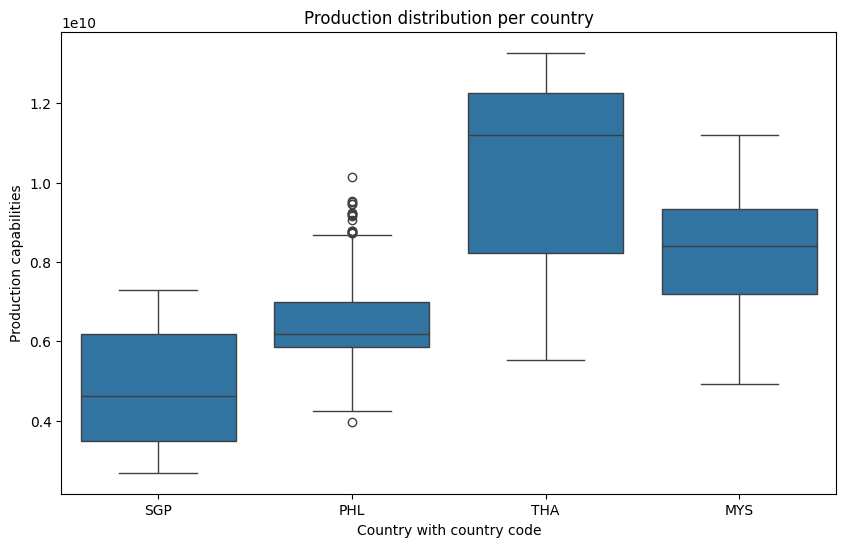

In [ ]:
# The box plot
plt.figure(figsize=(10,6))
sns.boxplot(x= 'countrycode', y= 'ind_prod_const_sa', data=df_dataset)
plt.title('Production distribution per country')
plt.xlabel('Country with country code')
plt.ylabel('Production capabilities')
plt.show()

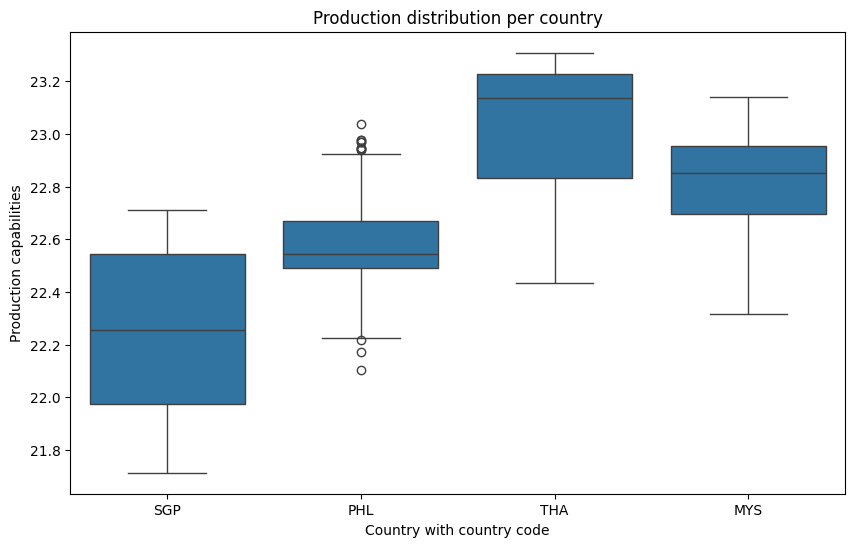

In [ ]:
# The box plot
plt.figure(figsize=(10,6))
sns.boxplot(x= 'countrycode', y= 'log_ind_prod_sa', data=df_dataset)
plt.title('Production distribution per country')
plt.xlabel('Country with country code')
plt.ylabel('Production capabilities')
plt.show()

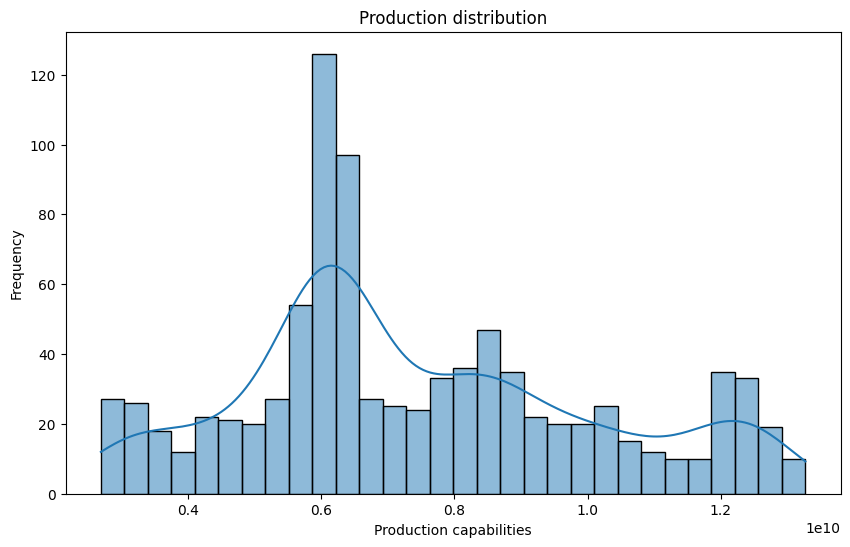

In [ ]:
# Normality test to check the curve only in plot
plt.figure(figsize=(10,6))
sns.histplot(df_dataset['ind_prod_const_sa'], kde=True, bins=30)
plt.title('Production distribution')
plt.xlabel('Production capabilities')
plt.ylabel('Frequency')
plt.show()


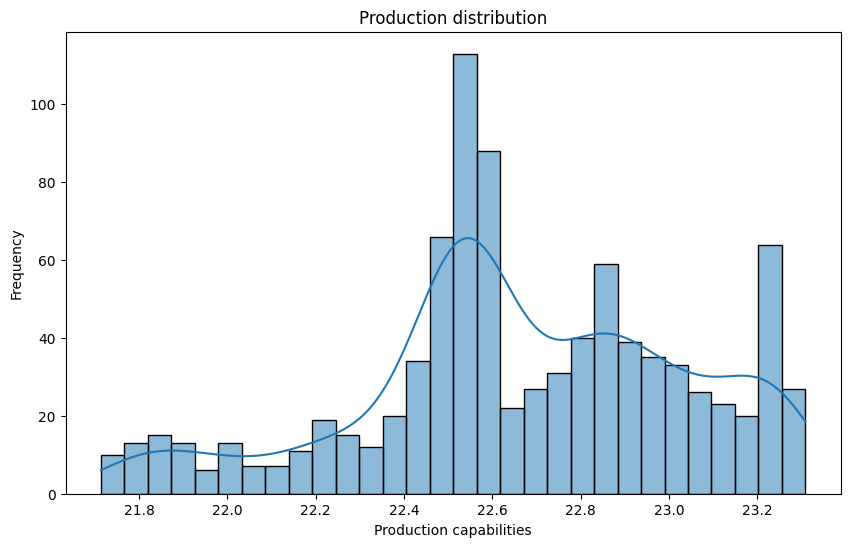

In [ ]:
# Normality test to check the curve only in plot
plt.figure(figsize=(10,6))
sns.histplot(df_dataset['log_ind_prod_sa'], kde=True, bins=30)
plt.title('Production distribution')
plt.xlabel('Production capabilities')
plt.ylabel('Frequency')
plt.show()


In [ ]:
#checking for correlation
correlation_f= df_dataset[['cpi_yoy_nsa','USA_lag','exchnage_rate_vs_usd','ind_prod_const_sa']].corr()
correlation_f


,cpi_yoy_nsa,USA_lag,exchnage_rate_vs_usd,ind_prod_const_sa
cpi_yoy_nsa,1.000000,0.129464,0.357678,-0.002609
USA_lag,0.129464,1.000000,-0.067300,0.523040
exchnage_rate_vs_usd,0.357678,-0.067300,1.000000,0.213621
ind_prod_const_sa,-0.002609,0.523040,0.213621,1.000000


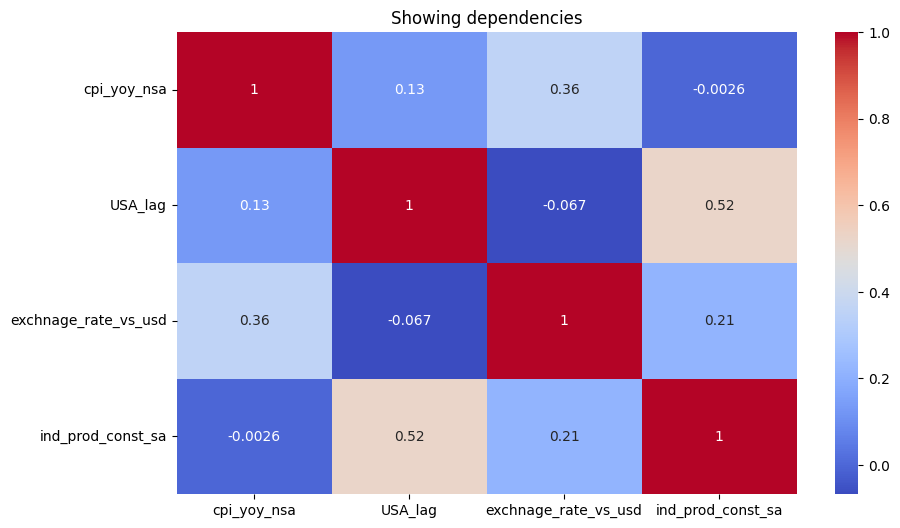

In [ ]:
#heatmap
plt.figure(figsize=(10,6))
sns.heatmap(correlation_f, annot= True, cmap='coolwarm')
plt.title('Showing dependencies')
plt.show()

In [ ]:
# Creating correlation log variables to check the changes and how much it is affected post filtering all outliers


In [ ]:
correlation_log= df_dataset[['cpi_yoy_nsa','exchnage_rate_vs_usd', 'export_gdp_pct', 'log_ind_prod_sa', 'log_usa_imp']].corr()
correlation_log

,cpi_yoy_nsa,exchnage_rate_vs_usd,export_gdp_pct,log_ind_prod_sa,log_usa_imp
cpi_yoy_nsa,1.000000,0.357678,-0.303041,0.055253,0.141590
exchnage_rate_vs_usd,0.357678,1.000000,-0.796807,0.251158,-0.063743
export_gdp_pct,-0.303041,-0.796807,1.000000,-0.549360,-0.060578
log_ind_prod_sa,0.055253,0.251158,-0.549360,1.000000,0.527976
log_usa_imp,0.141590,-0.063743,-0.060578,0.527976,1.000000


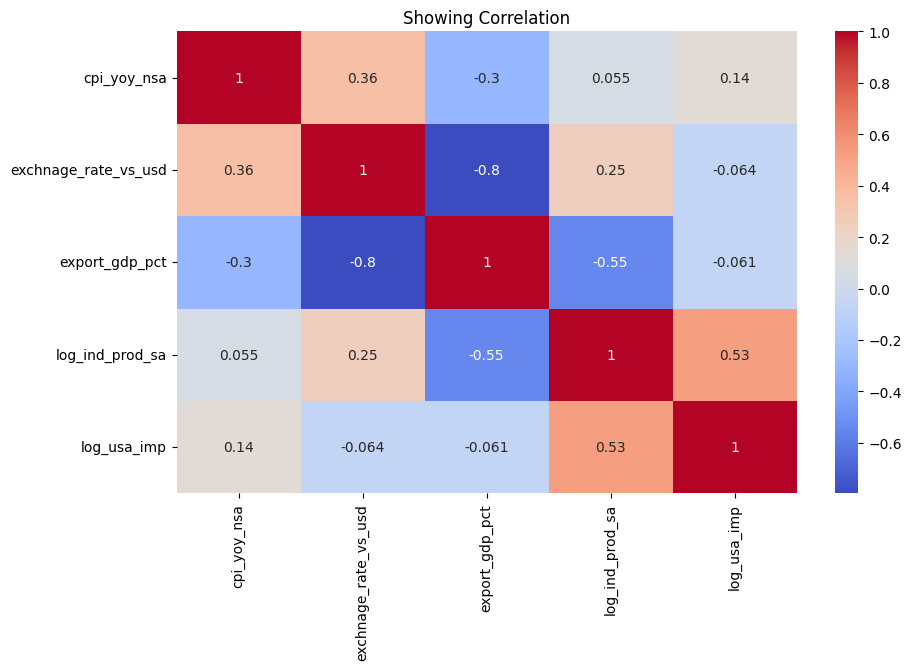

In [ ]:
# creating heatmap
plt.figure(figsize=(10,6))
sns.heatmap(correlation_log, annot= True, cmap='coolwarm')
plt.title('Showing Correlation')
plt.show()

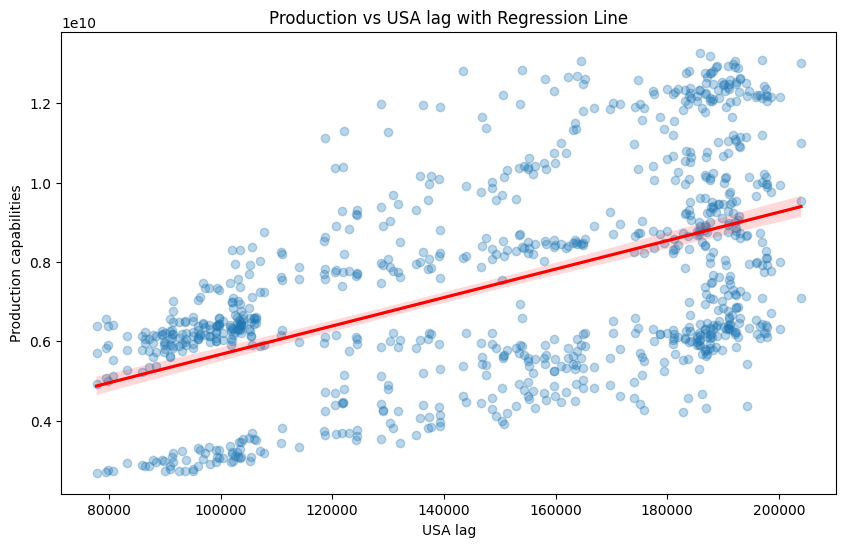

In [ ]:
# Creating a scatter plot to show the relationship between the production capacity of asia vs the USA lag

plt.figure(figsize=(10,6))
sns.regplot(x= 'USA_lag', y='ind_prod_const_sa', data= df_dataset, scatter_kws={'alpha':0.3}, line_kws={'color': 'red'})
plt.title('Production vs USA lag with Regression Line')
plt.xlabel('USA lag')
plt.ylabel('Production capabilities')
plt.show()

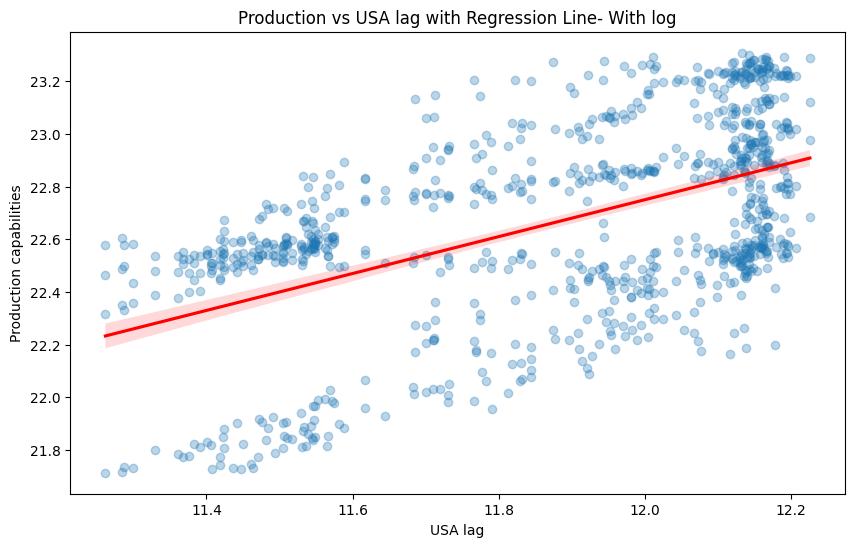

In [ ]:
# Creating a scatter plot to show the relationship between the production capacity of asia vs the USA lag post using log

plt.figure(figsize=(10,6))
sns.regplot(x= 'log_usa_imp', y='log_ind_prod_sa', data= df_dataset, scatter_kws={'alpha':0.3}, line_kws={'color': 'red'})
plt.title('Production vs USA lag with Regression Line- With log')
plt.xlabel('USA lag')
plt.ylabel('Production capabilities')
plt.show()

Hypothesis Testing:
The objective is clear for the assignment, we need to analyze whether the production scenario increases in Asian market when there is an excessive need or demand in US economy.

Null Hypothesis, *Ho* : There is no relation between the two economies neiher of the scenario affects the market.
Alternate Hypothesis, *H1* : States that yes there is a significant relation between the two economies as if the demand increases in US economy the production capacity will increase in Asian market as they need to produce more to export.

Here we will be using two variables:
Dependent variable(Y) will be Asian Market Industrial production index Seasonally adjusted ~ ***'ind_prod_const_sa'***
Independent variable is US Imports which is lagged by a month of time as shipping is a factor here ~ ***USA_lag***


In [ ]:
# Create country dummies
country_dummies = pd.get_dummies(df_dataset['countrycode'], drop_first=True).astype(int)

In [ ]:
#Creating a global value chain to check which country is more sensitive to US demands
df_dataset['gvc_integration']= df_dataset['log_usa_imp'] * df_dataset['export_gdp_pct']

In [ ]:
# combining log variable, dummie and interaction
X= pd.concat([df_dataset[['log_usa_imp','gvc_integration','cpi_yoy_nsa','exchnage_rate_vs_usd']], country_dummies], axis=1)

In [ ]:
# Hypothesis testing
import statsmodels.formula.api as sm
import statsmodels.api as sm_api # Import statsmodels.api


In [ ]:
X = sm_api.add_constant(X)
y = df_dataset['log_ind_prod_sa']
X = X.apply(pd.to_numeric, errors='coerce')

In [ ]:
# run the model
model = sm_api.OLS(endog=y, exog=X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_ind_prod_sa   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     827.4
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:05:27   Log-Likelihood:                 521.62
No. Observations:                 908   AIC:                            -1027.
Df Residuals:                     900   BIC:                            -988.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   14.4459 

In [ ]:
# Using Spearman and pearson correlational check
import scipy.stats as stats

In [ ]:
df_data_clean= df_dataset[['log_ind_prod_sa', 'log_usa_imp']].dropna()

In [ ]:
r_coeff, p_val= stats.pearsonr(df_data_clean['log_ind_prod_sa'], df_data_clean['log_usa_imp'])
print(f'Pearson Correlation Coefficient: {r_coeff}')
print(f'P-value: {p_val}')

Pearson Correlation Coefficient: 0.5279763283621385
P-value: 2.5694267093511764e-66


In [ ]:
# using spearmanr

In [ ]:
r_coeffS, p_vals= stats.spearmanr(df_data_clean['log_ind_prod_sa'], df_data_clean['log_usa_imp'])
print(f'Spearman Correlation Coefficient: {r_coeffS}')
print(f'P-value: {p_vals}')

Spearman Correlation Coefficient: 0.5055712041595554
P-value: 4.42366512966866e-60


In [ ]:
# Linear regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X = pd.concat([df_dataset[['log_usa_imp','gvc_integration','cpi_yoy_nsa','exchnage_rate_vs_usd']], country_dummies], axis=1)
X = sm_api.add_constant(X)
y= df_dataset['log_ind_prod_sa']

X_train, X_test, y_train, y_test= train_test_split(X,y, test_size= 0.2, random_state= 42)

lin_reg= LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Testing the model
y_pred= lin_reg.predict(X_test)


In [ ]:
#calculating r2_score
r_score= r2_score(y_test, y_pred)
print(f'R-squared Score: {r_score}')

R-squared Score: 0.8977224017278848


In [ ]:
# Training and testing for double check
train_score= lin_reg.score(X_train, y_train)
test_score= lin_reg.score(X_test, y_test)
print(f'Training Score: {train_score}')
print(f'Testing Score: {test_score}')

Training Score: 0.8565309066759728
Testing Score: 0.8977224017278848


In [ ]:
X = df_dataset[['log_usa_imp']]
y= df_dataset[['log_ind_prod_sa']]

X_train, X_test, y_train, y_test= train_test_split(X,y, test_size= 0.2, random_state= 42)

lin_reg= LinearRegression()
lin_reg.fit(X_train, y_train)



LinearRegression()

In [ ]:
y_pred= lin_reg.predict(X_test)
R_square= r2_score(y_test, y_pred)
print(f'Testing score: {R_square}')

Testing score: 0.30380426214398293
